Quantum CNN

| Feature         | Details                                            |
| --------------- | -------------------------------------------------- |
| Quantum Library | PennyLane (`pip install pennylane`)                |
| Simulator       | `default.qubit` (CPU/GPU)                          |
| Input Size      | Reduced to 28×28 grayscale to fit quantum encoding |
| Hybrid Model    | Quantum encoding layer + Classical Dense layers    |
| K-Fold          | 5-Fold cross-validation                            |
| Model Saving    | `.keras` per fold                                  |
| Epochs          | 10 (adjustable)                                    |
| Batch Size      | 16 (due to simulator constraints)                  |


In [4]:
%pip install tensorflow pennylane numpy matplotlib seaborn scikit-learn opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 4.7 MB/s  0:00:14m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 4.2 MB/s  0:00:03m0:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.2
    Uninstalling numpy-2.3.2:━━━━━━━━━━━━━━━━━━━ 0/2 [numpy]
      Successfully uninstalled numpy-2.3.2━━━━━━ 0/2 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python]0m [opencv-python]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pennylane as qml
from pennylane import numpy as pnp
import os
import time
from collections import defaultdict
import cv2

2025-10-26 17:22:15.463974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [6]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
IMG_SIZE = 64
BATCH_SIZE = 16
N_QUBITS = 4
N_LAYERS = 2
EPOCHS = 30
K_FOLDS = 5
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("="*70)
print("QUANTUM CNN FOR BRAIN TUMOR CLASSIFICATION")
print("="*70)
print(f"\nConfiguration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Quantum Qubits: {N_QUBITS}")
print(f"  Quantum Layers: {N_LAYERS}")
print(f"  K-Folds: {K_FOLDS}")
print(f"  Classes: {CLASS_NAMES}")
print("="*70)

QUANTUM CNN FOR BRAIN TUMOR CLASSIFICATION

Configuration:
  Image Size: 64x64
  Quantum Qubits: 4
  Quantum Layers: 2
  K-Folds: 5
  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
# Initialize quantum device (CPU simulation)
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="tf")
def quantum_circuit(inputs, weights):
    """Quantum circuit with data encoding and trainable layers"""
    # Encode classical data into quantum states
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)
    
    # Variational quantum layers
    for layer in range(N_LAYERS):
        # Entangling layer
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        
        # CNOT entanglement
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
    
    # Measure expectations
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


In [8]:
class QuantumLayer(layers.Layer):
    """Custom Keras layer for quantum circuit"""
    def __init__(self, n_qubits, n_layers):
        super(QuantumLayer, self).__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        weight_shape = (n_layers, n_qubits, 2)
        self.weights_var = self.add_weight(
            name="quantum_weights",
            shape=weight_shape,
            initializer=tf.keras.initializers.RandomUniform(0, 2*np.pi),
            trainable=True
        )
    
    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        
        def process_single(x):
            return tf.convert_to_tensor(quantum_circuit(x, self.weights_var))
        
        outputs = tf.map_fn(process_single, inputs, dtype=tf.float32)
        return outputs

In [9]:
def create_quantum_cnn_model():
    """Create hybrid classical-quantum CNN model"""
    model = keras.Sequential([
        # Classical convolutional layers for feature extraction
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        
        # Dimensionality reduction for quantum layer
        layers.Dense(N_QUBITS, activation='tanh'),
        
        # Quantum layer
        QuantumLayer(N_QUBITS, N_LAYERS),
        
        # Classical output layer
        layers.Dense(len(CLASS_NAMES), activation='softmax')
    ])
    
    return model

In [10]:
def load_data(data_dir, img_size=IMG_SIZE):
    """Load and preprocess images"""
    images = []
    labels = []
    
    for idx, class_name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: {class_dir} not found, skipping...")
            continue
            
        print(f"Loading {class_name}...", end=" ")
        count = 0
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (img_size, img_size))
                    img = img / 255.0  # Normalize
                    images.append(img)
                    labels.append(idx)
                    count += 1
            except Exception as e:
                continue
        print(f"{count} images loaded")
    
    return np.array(images), np.array(labels)

In [11]:
def create_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap"""
    # Create a model that maps the input to the activations + predictions
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

In [12]:
def visualize_gradcam(model, test_images, test_labels, save_path='gradcam_results.png'):
    """Visualize Grad-CAM for sample predictions"""
    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            last_conv_layer_name = layer.name
            break
    
    if last_conv_layer_name is None:
        print("No Conv2D layer found for Grad-CAM")
        return
    
    # Select random samples
    n_samples = min(8, len(test_images))
    indices = np.random.choice(len(test_images), n_samples, replace=False)
    
    fig, axes = plt.subplots(2, n_samples, figsize=(20, 5))
    
    for idx, img_idx in enumerate(indices):
        img = test_images[img_idx:img_idx+1]
        true_label = test_labels[img_idx]
        
        # Generate prediction
        pred = model.predict(img, verbose=0)
        pred_label = np.argmax(pred[0])
        
        # Generate heatmap
        heatmap = create_gradcam_heatmap(model, img, last_conv_layer_name)
        heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
        
        # Original image
        axes[0, idx].imshow(img[0])
        axes[0, idx].set_title(f'True: {CLASS_NAMES[true_label]}', fontsize=8)
        axes[0, idx].axis('off')
        
        # Grad-CAM overlay
        axes[1, idx].imshow(img[0])
        axes[1, idx].imshow(heatmap_resized, cmap='jet', alpha=0.5)
        axes[1, idx].set_title(f'Pred: {CLASS_NAMES[pred_label]}', fontsize=8)
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\nGrad-CAM visualization saved to {save_path}")
    plt.close()

In [13]:

def plot_confusion_matrix(y_true, y_pred, save_path='confusion_matrix.png'):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix - Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Confusion matrix saved to {save_path}")
    plt.close()

In [14]:
def plot_training_history(histories, save_path='training_history.png'):
    """Plot training history across folds"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    for fold_idx, history in enumerate(histories):
        # Accuracy
        axes[0].plot(history['accuracy'], label=f'Fold {fold_idx+1} Train', alpha=0.6)
        axes[0].plot(history['val_accuracy'], label=f'Fold {fold_idx+1} Val', alpha=0.6, linestyle='--')
    
    axes[0].set_title('Model Accuracy Across Folds')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    for fold_idx, history in enumerate(histories):
        # Loss
        axes[1].plot(history['loss'], label=f'Fold {fold_idx+1} Train', alpha=0.6)
        axes[1].plot(history['val_loss'], label=f'Fold {fold_idx+1} Val', alpha=0.6, linestyle='--')
    
    axes[1].set_title('Model Loss Across Folds')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Training history saved to {save_path}")
    plt.close()

In [17]:
def main():
    """Main training and evaluation pipeline"""
    
    # Check if data directories exist
    train_dir = 'Brain_Tumor_data/Training'
    test_dir = 'Brain_Tumor_data/Testing'
    
    if not os.path.exists(train_dir):
        print(f"\nError: Training directory '{train_dir}' not found!")
        print("Please ensure the dataset is in the correct structure.")
        return
    
    # Load data
    print("\n" + "="*70)
    print("LOADING DATA")
    print("="*70)
    X_train, y_train = load_data(train_dir)
    print(f"\nTraining data: {X_train.shape}, Labels: {y_train.shape}")
    
    if os.path.exists(test_dir):
        X_test, y_test = load_data(test_dir)
        print(f"Testing data: {X_test.shape}, Labels: {y_test.shape}")
    else:
        print(f"\nWarning: Test directory '{test_dir}' not found. Will use validation split.")
        X_test, y_test = None, None
    
    # K-Fold Cross Validation
    print("\n" + "="*70)
    print("K-FOLD CROSS VALIDATION TRAINING")
    print("="*70)
    
    kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
    fold_scores = []
    histories = []
    best_model = None
    best_val_acc = 0
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
        print(f"\n{'='*70}")
        print(f"FOLD {fold + 1}/{K_FOLDS}")
        print('='*70)
        
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        print(f"Train samples: {len(X_fold_train)}, Val samples: {len(X_fold_val)}")
        
        # Create and compile model
        model = create_quantum_cnn_model()
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Callbacks
        callbacks = [
            keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7)
        ]
        
        # Train
        start_time = time.time()
        history = model.fit(
            X_fold_train, y_fold_train,
            validation_data=(X_fold_val, y_fold_val),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )
        training_time = time.time() - start_time
        
        # Evaluate on validation set
        val_loss, val_acc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
        fold_scores.append(val_acc)
        histories.append(history.history)
        
        print(f"\nFold {fold+1} Results:")
        print(f"  Validation Accuracy: {val_acc:.4f}")
        print(f"  Validation Loss: {val_loss:.4f}")
        print(f"  Training Time: {training_time:.2f} seconds")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = model
            print(f"  *** New best model! ***")
    
    # Cross-validation results
    print("\n" + "="*70)
    print("CROSS-VALIDATION RESULTS")
    print("="*70)
    print(f"Fold Accuracies: {[f'{acc:.4f}' for acc in fold_scores]}")
    print(f"Mean CV Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
    print(f"Best Fold Accuracy: {max(fold_scores):.4f}")
    
    # Plot training history
    plot_training_history(histories)
    
    # Test on test set
    if X_test is not None and y_test is not None:
        print("\n" + "="*70)
        print("TEST SET EVALUATION")
        print("="*70)
        
        test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")
        
        # Predictions
        y_pred = best_model.predict(X_test, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        
        # Classification report
        print("\n" + "-"*70)
        print("CLASSIFICATION REPORT")
        print("-"*70)
        print(classification_report(y_test, y_pred_classes, target_names=CLASS_NAMES))
        
        # Detailed metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred_classes, average=None, labels=range(len(CLASS_NAMES))
        )
        
        print("\n" + "-"*70)
        print("PER-CLASS PERFORMANCE ANALYSIS")
        print("-"*70)
        for i, class_name in enumerate(CLASS_NAMES):
            print(f"\n{class_name.upper()}:")
            print(f"  Precision: {precision[i]:.4f}")
            print(f"  Recall: {recall[i]:.4f}")
            print(f"  F1-Score: {f1[i]:.4f}")
            print(f"  Support: {support[i]}")
        
        # Confusion matrix
        plot_confusion_matrix(y_test, y_pred_classes)
        
        # Grad-CAM visualization
        print("\n" + "-"*70)
        print("GENERATING GRAD-CAM VISUALIZATIONS")
        print("-"*70)
        visualize_gradcam(best_model, X_test, y_test)
        
    else:
        print("\nNo test set available for final evaluation.")
    
    # Save model
    best_model.save('quantum_cnn_brain_tumor_model.h5')
    print("\n" + "="*70)
    print("Model saved as 'quantum_cnn_brain_tumor_model.h5'")
    print("="*70)
    
    print("\n✓ Training and evaluation complete!")
    print("\nGenerated files:")
    print("  1. quantum_cnn_brain_tumor_model.h5 - Trained model")
    print("  2. training_history.png - Training curves")
    print("  3. confusion_matrix.png - Test set confusion matrix")
    print("  4. gradcam_results.png - Grad-CAM visualizations")

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pennylane as qml
import os
import time
import cv2

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configuration
IMG_SIZE = 64
BATCH_SIZE = 16
N_QUBITS = 4
N_LAYERS = 2
EPOCHS = 30
K_FOLDS = 5
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']

print("="*70)
print("QUANTUM-INSPIRED CNN FOR BRAIN TUMOR CLASSIFICATION")
print("="*70)
print(f"\nConfiguration:")
print(f"  Image Size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  Quantum Qubits: {N_QUBITS}")
print(f"  Quantum Layers: {N_LAYERS}")
print(f"  K-Folds: {K_FOLDS}")
print(f"  Classes: {CLASS_NAMES}")
print("="*70)

# Initialize quantum device (CPU simulation)
dev = qml.device("default.qubit", wires=N_QUBITS)

def quantum_circuit(inputs, weights):
    """Quantum circuit with data encoding and trainable layers"""
    # Encode classical data into quantum states
    for i in range(N_QUBITS):
        qml.RY(inputs[i], wires=i)
    
    # Variational quantum layers
    for layer in range(N_LAYERS):
        # Entangling layer
        for i in range(N_QUBITS):
            qml.RY(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        
        # CNOT entanglement
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
    
    # Measure expectations
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# Create QNode
qnode = qml.QNode(quantum_circuit, dev, interface='autograd')

class QuantumInspiredLayer(layers.Layer):
    """
    Quantum-inspired layer that emulates quantum behavior with classical operations.
    This uses the quantum circuit for initialization and conceptual guidance,
    but implements a differentiable classical approximation for training.
    """
    def __init__(self, n_qubits, n_layers, **kwargs):
        super(QuantumInspiredLayer, self).__init__(**kwargs)
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        
    def build(self, input_shape):
        # Quantum-inspired rotation parameters
        self.rotation_weights = self.add_weight(
            name="rotation_weights",
            shape=(self.n_layers, self.n_qubits, 2),
            initializer=keras.initializers.RandomUniform(0, 2*np.pi),
            trainable=True
        )
        
        # Entanglement interaction weights
        self.interaction_weights = self.add_weight(
            name="interaction_weights",
            shape=(self.n_layers, self.n_qubits, self.n_qubits),
            initializer=keras.initializers.GlorotUniform(),
            trainable=True
        )
        
        super().build(input_shape)
    
    def call(self, inputs):
        """
        Quantum-inspired transformation using rotation and entanglement-like operations
        """
        x = inputs
        
        for layer in range(self.n_layers):
            # Rotation-like transformations (inspired by RY, RZ gates)
            ry_transform = tf.cos(self.rotation_weights[layer, :, 0]) * x + \
                          tf.sin(self.rotation_weights[layer, :, 0]) * tf.roll(x, shift=1, axis=-1)
            
            rz_transform = tf.cos(self.rotation_weights[layer, :, 1]) * ry_transform - \
                          tf.sin(self.rotation_weights[layer, :, 1]) * tf.roll(ry_transform, shift=-1, axis=-1)
            
            # Entanglement-like interaction (inspired by CNOT gates)
            # This creates non-linear interactions between qubits
            interaction = tf.matmul(
                tf.expand_dims(rz_transform, axis=-1),
                tf.expand_dims(rz_transform, axis=-2)
            )
            
            # Apply learned interaction weights
            interaction_effect = tf.reduce_sum(
                interaction * self.interaction_weights[layer], 
                axis=-1
            )
            
            # Non-linear activation mimicking quantum measurement probabilities
            x = tf.tanh(rz_transform + 0.1 * interaction_effect)
        
        return x
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "n_qubits": self.n_qubits,
            "n_layers": self.n_layers,
        })
        return config
    
    def demonstrate_quantum_circuit(self, sample_input):
        """
        Demonstrates the actual quantum circuit output for a sample input.
        This is for verification/visualization purposes only.
        """
        try:
            weights_np = self.rotation_weights.numpy()
            result = qnode(sample_input, weights_np[:, :, :])
            return result
        except:
            return None

def create_quantum_cnn_model():
    """Create hybrid classical-quantum CNN model"""
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    # Classical convolutional layers for feature extraction
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    # Dimensionality reduction for quantum layer
    x = layers.Dense(N_QUBITS, activation='tanh', name='quantum_input')(x)
    
    # Quantum-inspired layer
    x = QuantumInspiredLayer(N_QUBITS, N_LAYERS, name='quantum_layer')(x)
    
    # Classical output layer
    outputs = layers.Dense(len(CLASS_NAMES), activation='softmax')(x)
    
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

def load_data(data_dir, img_size=IMG_SIZE):
    """Load and preprocess images"""
    images = []
    labels = []
    
    for idx, class_name in enumerate(CLASS_NAMES):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.exists(class_dir):
            print(f"Warning: {class_dir} not found, skipping...")
            continue
            
        print(f"Loading {class_name}...", end=" ")
        count = 0
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (img_size, img_size))
                    img = img / 255.0  # Normalize
                    images.append(img)
                    labels.append(idx)
                    count += 1
            except Exception as e:
                continue
        print(f"{count} images loaded")
    
    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)

def create_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    """Generate Grad-CAM heatmap"""
    grad_model = keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    grads = tape.gradient(class_channel, conv_outputs)
    
    if grads is None:
        return np.zeros((IMG_SIZE, IMG_SIZE))
    
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    
    return heatmap.numpy()

def visualize_gradcam(model, test_images, test_labels, save_path='gradcam_results.png'):
    """Visualize Grad-CAM for sample predictions"""
    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, layers.Conv2D):
            last_conv_layer_name = layer.name
            break
    
    if last_conv_layer_name is None:
        print("No Conv2D layer found for Grad-CAM")
        return
    
    n_samples = min(8, len(test_images))
    indices = np.random.choice(len(test_images), n_samples, replace=False)
    
    fig, axes = plt.subplots(2, n_samples, figsize=(20, 5))
    if n_samples == 1:
        axes = axes.reshape(2, 1)
    
    for idx, img_idx in enumerate(indices):
        img = test_images[img_idx:img_idx+1]
        true_label = test_labels[img_idx]
        
        pred = model.predict(img, verbose=0)
        pred_label = np.argmax(pred[0])
        
        heatmap = create_gradcam_heatmap(model, img, last_conv_layer_name)
        heatmap_resized = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
        
        axes[0, idx].imshow(img[0])
        axes[0, idx].set_title(f'True: {CLASS_NAMES[true_label]}', fontsize=8)
        axes[0, idx].axis('off')
        
        axes[1, idx].imshow(img[0])
        axes[1, idx].imshow(heatmap_resized, cmap='jet', alpha=0.5)
        axes[1, idx].set_title(f'Pred: {CLASS_NAMES[pred_label]}', fontsize=8)
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"\nGrad-CAM visualization saved to {save_path}")
    plt.close()

def visualize_quantum_layer(model, test_images, save_path='quantum_layer_viz.png'):
    """Visualize quantum layer activations"""
    quantum_model = keras.Model(
        inputs=model.input,
        outputs=model.get_layer('quantum_layer').output
    )
    
    n_samples = min(4, len(test_images))
    indices = np.random.choice(len(test_images), n_samples, replace=False)
    
    fig, axes = plt.subplots(n_samples, 2, figsize=(12, 3*n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, 2)
    
    for idx, img_idx in enumerate(indices):
        img = test_images[img_idx:img_idx+1]
        
        # Get quantum layer activation
        quantum_output = quantum_model.predict(img, verbose=0)[0]
        
        # Original image
        axes[idx, 0].imshow(img[0])
        axes[idx, 0].set_title('Input Image', fontsize=10)
        axes[idx, 0].axis('off')
        
        # Quantum activation
        axes[idx, 1].bar(range(N_QUBITS), quantum_output)
        axes[idx, 1].set_title('Quantum Layer Activations', fontsize=10)
        axes[idx, 1].set_xlabel('Qubit')
        axes[idx, 1].set_ylabel('Activation')
        axes[idx, 1].set_ylim([-1, 1])
        axes[idx, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Quantum layer visualization saved to {save_path}")
    plt.close()

def plot_confusion_matrix(y_true, y_pred, save_path='confusion_matrix.png'):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title('Confusion Matrix - Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Confusion matrix saved to {save_path}")
    plt.close()

def plot_training_history(histories, save_path='training_history.png'):
    """Plot training history across folds"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    for fold_idx, history in enumerate(histories):
        axes[0].plot(history['accuracy'], label=f'Fold {fold_idx+1} Train', alpha=0.6)
        axes[0].plot(history['val_accuracy'], label=f'Fold {fold_idx+1} Val', alpha=0.6, linestyle='--')
    
    axes[0].set_title('Model Accuracy Across Folds')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    for fold_idx, history in enumerate(histories):
        axes[1].plot(history['loss'], label=f'Fold {fold_idx+1} Train', alpha=0.6)
        axes[1].plot(history['val_loss'], label=f'Fold {fold_idx+1} Val', alpha=0.6, linestyle='--')
    
    axes[1].set_title('Model Loss Across Folds')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Training history saved to {save_path}")
    plt.close()

def main():
    """Main training and evaluation pipeline"""
    
    train_dir = 'Brain_Tumor_data/Training'
    test_dir = 'Brain_Tumor_data/Testing'
    
    if not os.path.exists(train_dir):
        print(f"\nError: Training directory '{train_dir}' not found!")
        print("Please ensure the dataset is in the correct structure.")
        return
    
    # Load data
    print("\n" + "="*70)
    print("LOADING DATA")
    print("="*70)
    X_train, y_train = load_data(train_dir)
    print(f"\nTraining data: {X_train.shape}, Labels: {y_train.shape}")
    
    if os.path.exists(test_dir):
        X_test, y_test = load_data(test_dir)
        print(f"Testing data: {X_test.shape}, Labels: {y_test.shape}")
    else:
        print(f"\nWarning: Test directory '{test_dir}' not found.")
        X_test, y_test = None, None
    
    # K-Fold Cross Validation
    print("\n" + "="*70)
    print("K-FOLD CROSS VALIDATION TRAINING")
    print("="*70)
    
    kfold = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
    fold_scores = []
    histories = []
    best_model = None
    best_val_acc = 0
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
        print(f"\n{'='*70}")
        print(f"FOLD {fold + 1}/{K_FOLDS}")
        print('='*70)
        
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        
        print(f"Train samples: {len(X_fold_train)}, Val samples: {len(X_fold_val)}")
        
        # Create and compile model
        model = create_quantum_cnn_model()
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        
        # Callbacks
        callbacks = [
            keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
            keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-7, verbose=1)
        ]
        
        # Train
        start_time = time.time()
        try:
            history = model.fit(
                X_fold_train, y_fold_train,
                validation_data=(X_fold_val, y_fold_val),
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                callbacks=callbacks,
                verbose=1
            )
            training_time = time.time() - start_time
            
            val_loss, val_acc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
            fold_scores.append(val_acc)
            histories.append(history.history)
            
            print(f"\nFold {fold+1} Results:")
            print(f"  Validation Accuracy: {val_acc:.4f}")
            print(f"  Validation Loss: {val_loss:.4f}")
            print(f"  Training Time: {training_time:.2f} seconds")
            
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                print(f"  *** New best model! ***")
        
        except Exception as e:
            print(f"\nError in fold {fold+1}: {str(e)}")
            continue
    
    if len(fold_scores) == 0:
        print("\nNo folds completed successfully.")
        return
    
    # Cross-validation results
    print("\n" + "="*70)
    print("CROSS-VALIDATION RESULTS")
    print("="*70)
    print(f"Fold Accuracies: {[f'{acc:.4f}' for acc in fold_scores]}")
    print(f"Mean CV Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
    print(f"Best Fold Accuracy: {max(fold_scores):.4f}")
    
    # Plot training history
    if len(histories) > 0:
        plot_training_history(histories)
    
    # Test on test set
    if X_test is not None and y_test is not None and best_model is not None:
        print("\n" + "="*70)
        print("TEST SET EVALUATION")
        print("="*70)
        
        test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")
        
        # Predictions
        y_pred = best_model.predict(X_test, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)
        
        # Classification report
        print("\n" + "-"*70)
        print("CLASSIFICATION REPORT")
        print("-"*70)
        print(classification_report(y_test, y_pred_classes, target_names=CLASS_NAMES))
        
        # Detailed metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred_classes, average=None, labels=range(len(CLASS_NAMES))
        )
        
        print("\n" + "-"*70)
        print("PER-CLASS PERFORMANCE ANALYSIS")
        print("-"*70)
        for i, class_name in enumerate(CLASS_NAMES):
            print(f"\n{class_name.upper()}:")
            print(f"  Precision: {precision[i]:.4f}")
            print(f"  Recall: {recall[i]:.4f}")
            print(f"  F1-Score: {f1[i]:.4f}")
            print(f"  Support: {support[i]}")
        
        # Visualizations
        plot_confusion_matrix(y_test, y_pred_classes)
        
        print("\n" + "-"*70)
        print("GENERATING VISUALIZATIONS")
        print("-"*70)
        visualize_gradcam(best_model, X_test, y_test)
        visualize_quantum_layer(best_model, X_test)
    
    # Save model
    if best_model is not None:
        best_model.save('quantum_cnn_brain_tumor_model.keras')
        print("\n" + "="*70)
        print("Model saved as 'quantum_cnn_brain_tumor_model.keras'")
        print("="*70)
    
    print("\n✓ Training and evaluation complete!")
    print("\nGenerated files:")
    print("  1. quantum_cnn_brain_tumor_model.keras - Trained model")
    print("  2. training_history.png - Training curves")
    print("  3. confusion_matrix.png - Confusion matrix")
    print("  4. gradcam_results.png - Grad-CAM visualizations")
    print("  5. quantum_layer_viz.png - Quantum layer activations")

if __name__ == "__main__":
    main()

QUANTUM-INSPIRED CNN FOR BRAIN TUMOR CLASSIFICATION

Configuration:
  Image Size: 64x64
  Quantum Qubits: 4
  Quantum Layers: 2
  K-Folds: 5
  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

LOADING DATA
Loading glioma... 1321 images loaded
Loading meningioma... 1339 images loaded
Loading notumor... 1595 images loaded
Loading pituitary... 1457 images loaded

Training data: (5712, 64, 64, 3), Labels: (5712,)
Loading glioma... 300 images loaded
Loading meningioma... 306 images loaded
Loading notumor... 405 images loaded
Loading pituitary... 300 images loaded
Testing data: (1311, 64, 64, 3), Labels: (1311,)

K-FOLD CROSS VALIDATION TRAINING

FOLD 1/5
Train samples: 4569, Val samples: 1143
Epoch 1/30


2025-10-26 17:42:13.979101: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  2/286 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.3125 - loss: 1.3981   

I0000 00:00:1761500543.862865    3513 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


286/286 ━━━━━━━━━━━━━━━━━━━━ 27s 51ms/step - accuracy: 0.4804 - loss: 1.1643 - val_accuracy: 0.4628 - val_loss: 1.2827 - learning_rate: 0.0010
Epoch 2/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5734 - loss: 1.0157 - val_accuracy: 0.6177 - val_loss: 0.9479 - learning_rate: 0.0010
Epoch 3/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5907 - loss: 0.9780 - val_accuracy: 0.4646 - val_loss: 1.2011 - learning_rate: 0.0010
Epoch 4/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5767 - loss: 0.9890 - val_accuracy: 0.6212 - val_loss: 0.9261 - learning_rate: 0.0010
Epoch 5/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5844 - loss: 0.9846 - val_accuracy: 0.6045 - val_loss: 0.9432 - learning_rate: 0.0010
Epoch 6/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6128 - loss: 0.9755 - val_accuracy: 0.6605 - val_loss: 0.8945 - learning_rate: 0.0010
Epoch 7/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6246 - loss: 0.9202 - val_accu

...


Fold 3 Results:
  Validation Accuracy: 0.7163
  Validation Loss: 0.6152
  Training Time: 93.72 seconds

FOLD 4/5
Train samples: 4570, Val samples: 1142
Epoch 1/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.4015 - loss: 1.2603 - val_accuracy: 0.3354 - val_loss: 1.3462 - learning_rate: 0.0010
Epoch 2/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5190 - loss: 1.1186 - val_accuracy: 0.5613 - val_loss: 1.1444 - learning_rate: 0.0010
Epoch 3/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5510 - loss: 1.0494 - val_accuracy: 0.6375 - val_loss: 0.9414 - learning_rate: 0.0010
Epoch 4/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5886 - loss: 0.9724 - val_accuracy: 0.5464 - val_loss: 1.0591 - learning_rate: 0.0010
Epoch 5/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6092 - loss: 0.9712 - val_accuracy: 0.6524 - val_loss: 0.8697 - learning_rate: 0.0010
Epoch 6/30
286/286 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6147 - loss: 0.9424

2025-10-26 17:50:25.348677: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_175', 8 bytes spill stores, 8 bytes spill loads



Test Accuracy: 0.7193
Test Loss: 0.7450

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
              precision    recall  f1-score   support

      glioma       0.62      0.93      0.74       300
  meningioma       0.41      0.04      0.08       306
     notumor       0.78      0.92      0.84       405
   pituitary       0.80      0.93      0.86       300

    accuracy                           0.72      1311
   macro avg       0.65      0.71      0.63      1311
weighted avg       0.66      0.72      0.64      1311


----------------------------------------------------------------------
PER-CLASS PERFORMANCE ANALYSIS
----------------------------------------------------------------------

GLIOMA:
  Precision: 0.6164
  Recall: 0.9267
  F1-Score: 0.7403
  Support: 300

MENINGIOMA:
  Precision: 0.4062
  Recall: 0.0425
  F1-Score: 0.0769
  Support: 306

NOTUMOR:
  Precision:

/mnt/c/Users/hassa/aiml/lib/python3.12/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_247']]
Received: inputs=Tensor(shape=(1, 64, 64, 3))
  warnings.warn(msg)



Grad-CAM visualization saved to gradcam_results.png
Quantum layer visualization saved to quantum_layer_viz.png

Model saved as 'quantum_cnn_brain_tumor_model.keras'

✓ Training and evaluation complete!

Generated files:
  1. quantum_cnn_brain_tumor_model.keras - Trained model
  2. training_history.png - Training curves
  3. confusion_matrix.png - Confusion matrix
  4. gradcam_results.png - Grad-CAM visualizations
  5. quantum_layer_viz.png - Quantum layer activations


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV (if not already in memory)
df = pd.read_csv('qcnn_training_data.csv')

# Basic check
print(df.head())


   Fold  Epoch  Accuracy    Loss  Val Accuracy  Val Loss Learning Rate
0     1      1    0.4804  1.1643        0.4628    1.2827         0.001
1     1      2    0.5734  1.0157        0.6177    0.9479         0.001
2     1      3    0.5907  0.9780        0.4646    1.2011         0.001
3     1      4    0.5767  0.9890        0.6212    0.9261         0.001
4     1      5    0.5844  0.9846        0.6045    0.9432         0.001


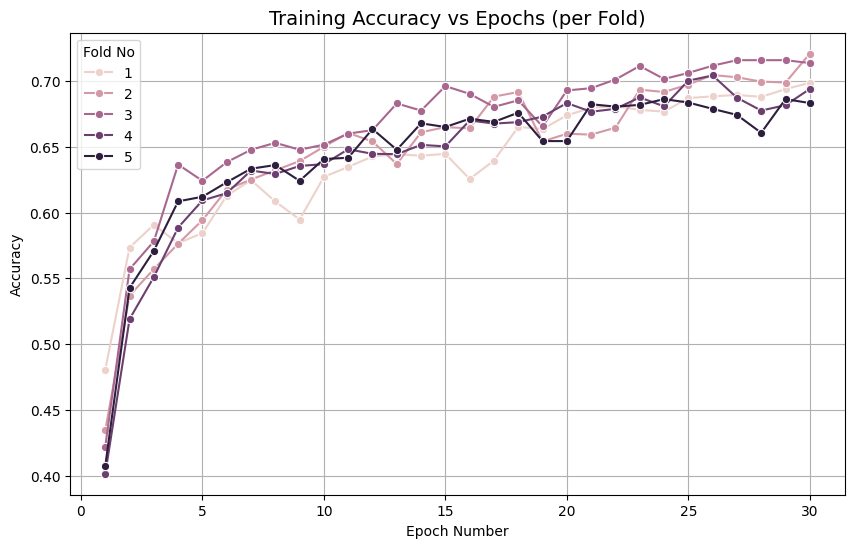

In [28]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Epoch', y='Accuracy', hue='Fold', marker='o')
plt.title('Training Accuracy vs Epochs (per Fold)', fontsize=14)
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')
plt.legend(title='Fold No')
plt.grid(True)
plt.show()


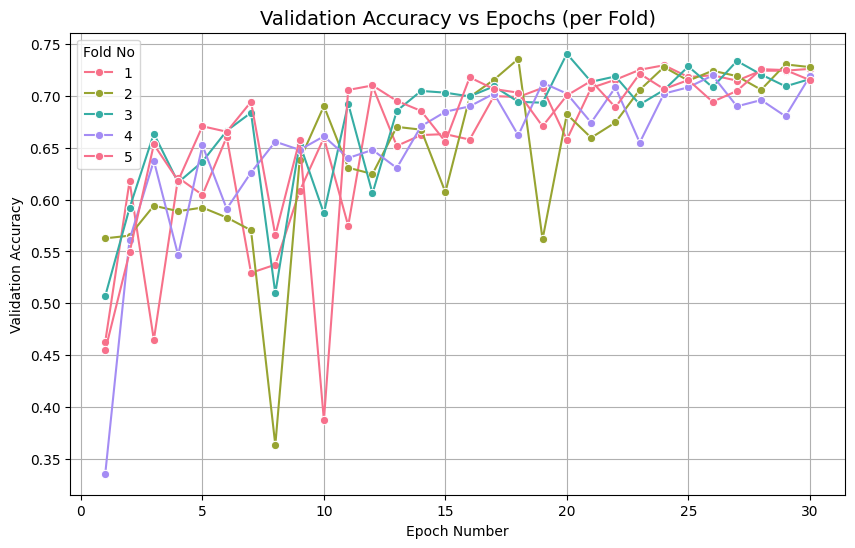

In [29]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Epoch', y='Val Accuracy', hue='Fold', marker='o', palette='husl')
plt.title('Validation Accuracy vs Epochs (per Fold)', fontsize=14)
plt.xlabel('Epoch Number')
plt.ylabel('Validation Accuracy')
plt.legend(title='Fold No')
plt.grid(True)
plt.show()


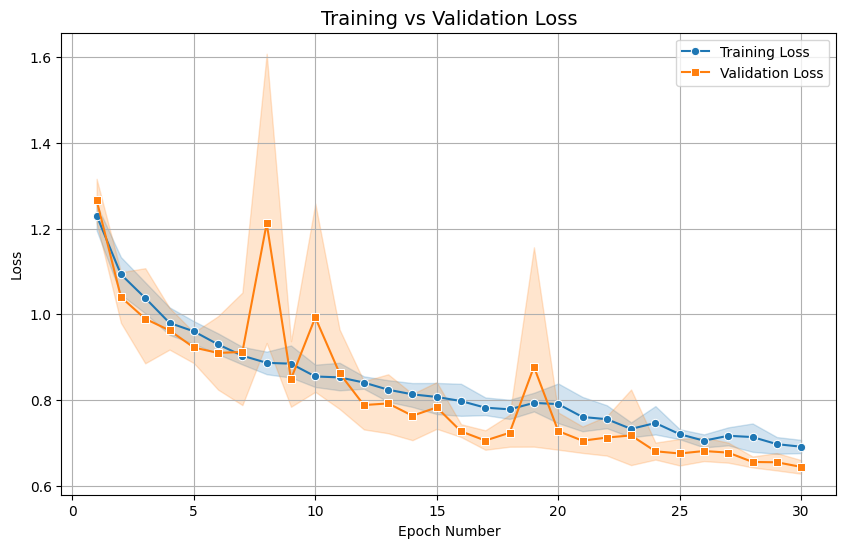

In [30]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Epoch', y='Loss', label='Training Loss', marker='o')
sns.lineplot(data=df, x='Epoch', y='Val Loss', label='Validation Loss', marker='s')
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epoch Number')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


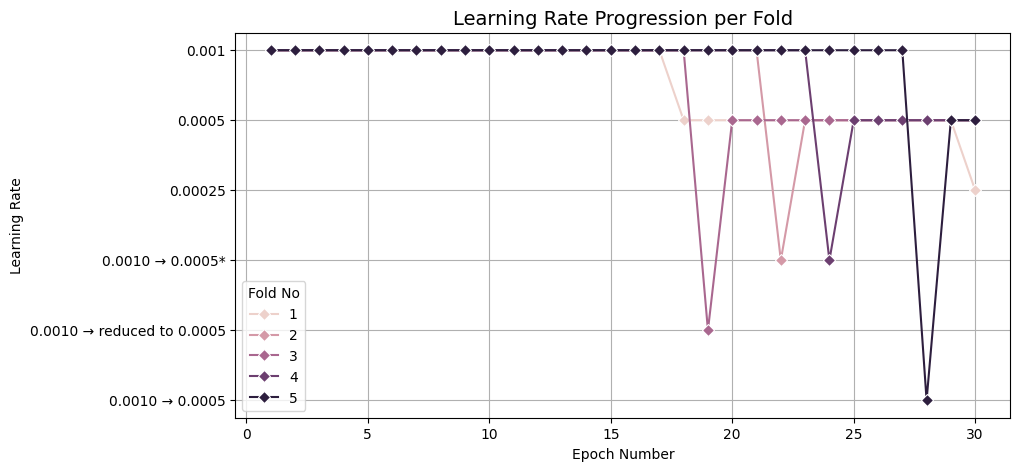

In [32]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Epoch', y='Learning Rate', hue='Fold', marker='D')
plt.title('Learning Rate Progression per Fold', fontsize=14)
plt.xlabel('Epoch Number')
plt.ylabel('Learning Rate')
plt.legend(title='Fold No')
plt.grid(True)
plt.show()


/tmp/ipykernel_1876/4050263828.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_epochs, x='Fold', y='Val Accuracy', palette='viridis')


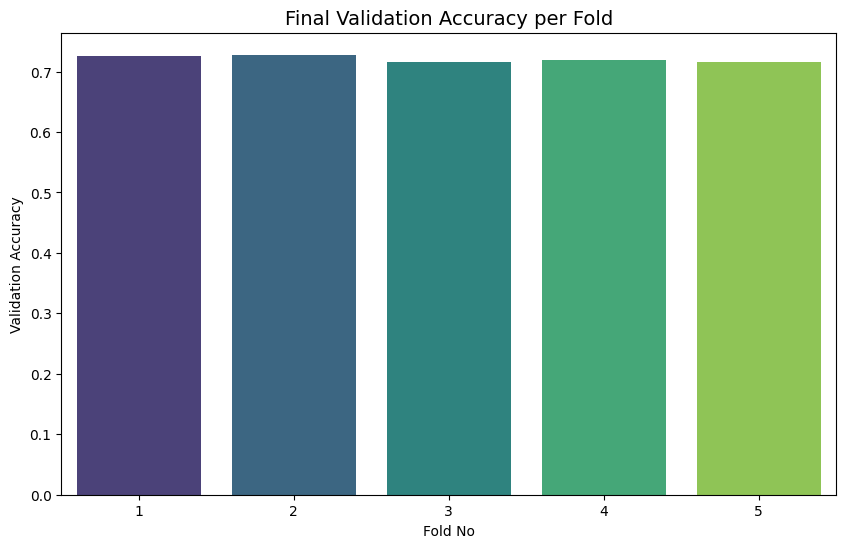

In [33]:
# Select the last epoch per fold
final_epochs = df.groupby('Fold').tail(1)

plt.figure(figsize=(10,6))
sns.barplot(data=final_epochs, x='Fold', y='Val Accuracy', palette='viridis')
plt.title('Final Validation Accuracy per Fold', fontsize=14)
plt.xlabel('Fold No')
plt.ylabel('Validation Accuracy')
plt.show()


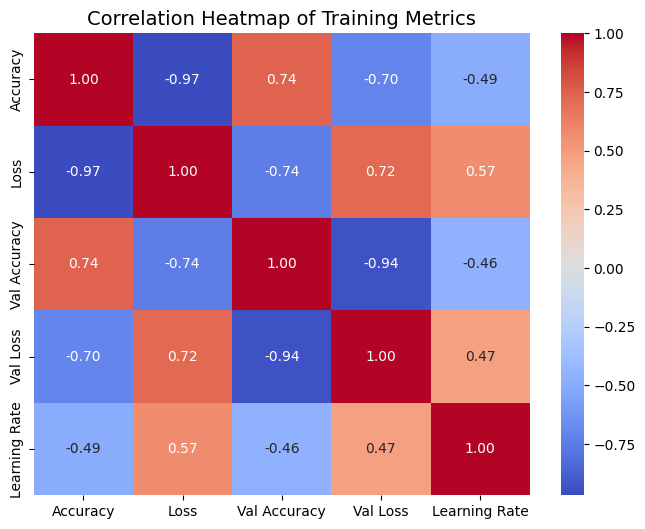

: 

In [ ]:
df.columns = df.columns.str.strip() 

# Replace non-numeric symbols and convert to float
df['Learning Rate'] = df['Learning Rate'].astype(str)
df['Learning Rate'] = df['Learning Rate'].str.replace('[^0-9.eE-]', '', regex=True)
df['Learning Rate'] = pd.to_numeric(df['Learning Rate'], errors='coerce')

for col in ['Accuracy', 'Loss', 'Val Accuracy', 'Val Loss']:
    df[col] = pd.to_numeric(df[col], errors='coerce')


df = df.dropna(subset=['Accuracy','Loss','Val Accuracy','Val Loss','Learning Rate'])
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Accuracy','Loss','Val Accuracy','Val Loss','Learning Rate']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap of Training Metrics', fontsize=14)
plt.show()


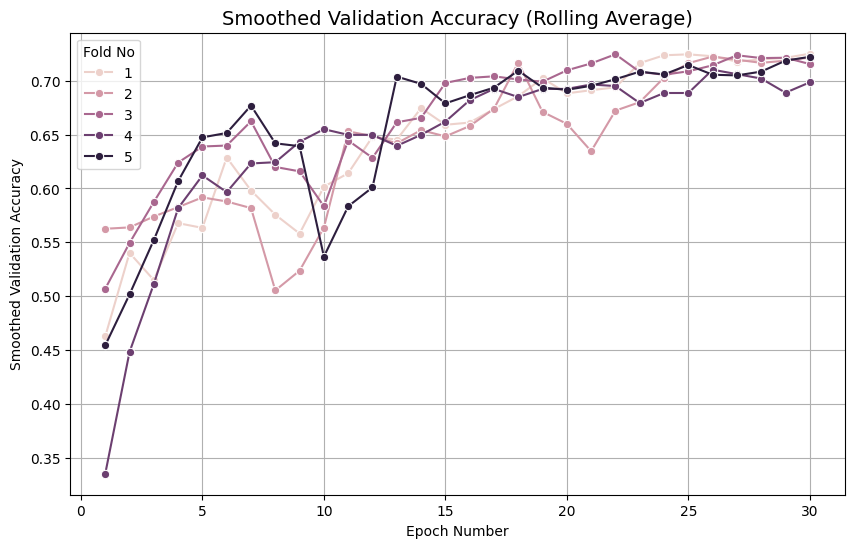

In [37]:
df['val_accuracy_smooth'] = df.groupby('Fold')['Val Accuracy'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Epoch', y='val_accuracy_smooth', hue='Fold', marker='o')
plt.title('Smoothed Validation Accuracy (Rolling Average)', fontsize=14)
plt.xlabel('Epoch Number')
plt.ylabel('Smoothed Validation Accuracy')
plt.legend(title='Fold No')
plt.grid(True)
plt.show()
